# End of Studies Project : UM6P Campus air quality prediction dashboard

## I. Understanding the data

### Uploading the dataset

In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

df.head()

Saving openaq_merged.csv to openaq_merged.csv


,location_id,location_name,datetimeUtc,datetimeLocal,timezone,latitude,longitude,country_iso,isMobile,isMonitor,owner_name,provider,pm1,pm25,relativehumidity,temperature,um003
0,2851582,Marrakech-Residence Mima,2025-05-24 12:00:00+00:00,2025-05-24T13:00:00+01:00,Africa/Casablanca,31.660974,-8.027883,NaN,NaN,NaN,campus,AirGradient,7.760000,11.660000,24.180000,30.900000,1442.800049
1,2851582,Marrakech-Residence Mima,2025-05-24 13:00:00+00:00,2025-05-24T14:00:00+01:00,Africa/Casablanca,31.660974,-8.027883,NaN,NaN,NaN,campus,AirGradient,9.639583,14.461905,24.288839,30.227679,1785.342255
2,2851582,Marrakech-Residence Mima,2025-05-24 14:00:00+00:00,2025-05-24T15:00:00+01:00,Africa/Casablanca,31.660974,-8.027883,NaN,NaN,NaN,campus,AirGradient,9.207143,13.776935,22.832292,29.978571,1692.308024
3,2851582,Marrakech-Residence Mima,2025-05-24 15:00:00+00:00,2025-05-24T16:00:00+01:00,Africa/Casablanca,31.660974,-8.027883,NaN,NaN,NaN,campus,AirGradient,7.754464,11.386161,20.548363,30.078572,1485.172628
4,2851582,Marrakech-Residence Mima,2025-05-24 16:00:00+00:00,2025-05-24T17:00:00+01:00,Africa/Casablanca,31.660974,-8.027883,NaN,NaN,NaN,campus,AirGradient,6.022917,8.662946,19.023512,30.411904,1179.092270


### Dropping unecessary columns

In [ ]:
cols_to_drop = [
    "country_iso",
    "isMobile",
    "isMonitor",
    "datetimeLocal",
    "timezone",
    "provider",
    "owner_name",
]

df = df.drop(columns=cols_to_drop)

print(f"Remaining columns: {df.columns.tolist()}")
print(f"Shape: {df.shape}")


Remaining columns: ['location_id', 'location_name', 'datetimeUtc', 'latitude', 'longitude', 'pm1', 'pm25', 'relativehumidity', 'temperature', 'um003']
Shape: (15172, 10)


## II. Cleaning the dataset

### Clean column names

In [ ]:
df.columns = df.columns.str.strip()

### Convert datetime column and set as index

In [ ]:
df['datetimeUtc'] = pd.to_datetime(df['datetimeUtc'], format='mixed', errors='coerce')
df = df.sort_values('datetimeUtc')
df = df.set_index('datetimeUtc')

### Check missing values BEFORE handling them

In [ ]:
print("Missing values before handling:")
print(df.isna().sum())
df = df.interpolate(method='time')

Missing values before handling:
location_id         0
location_name       0
latitude            0
longitude           0
pm1                 0
pm25                0
relativehumidity    0
temperature         0
um003               0
dtype: int64


/tmp/ipykernel_33488/3556601093.py:3: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='time')


## III. Exploratory data analysis

### Import necessities

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### Define polluants and feature groups

In [ ]:
polluants   = ['pm1', 'pm25', 'um003']
env_features = ['temperature', 'relativehumidity']
all_features  = polluants + env_features

print("Pollutants (targets & predictors):", polluants)
print("Environmental features (predictors only):", env_features)
print()
print("Feature matrix per model:")
for t in polluants:
    preds = [c for c in all_features if c != t]
    print(f"  predict {t:6s}  ←  {preds}")


Pollutants (targets & predictors): ['pm1', 'pm25', 'um003']
Environmental features (predictors only): ['temperature', 'relativehumidity']

Feature matrix per model:
  predict pm1     ←  ['pm25', 'um003', 'temperature', 'relativehumidity']
  predict pm25    ←  ['pm1', 'um003', 'temperature', 'relativehumidity']
  predict um003   ←  ['pm1', 'pm25', 'temperature', 'relativehumidity']


### Descriptive statistics

In [ ]:
print(df[all_features].describe().round(3))

print("\n── Skewness & Kurtosis ──")
for col in all_features:
    sk = stats.skew(df[col].dropna())
    ku = stats.kurtosis(df[col].dropna())
    print(f"  {col:20s}  skew={sk:6.2f}  kurtosis={ku:7.2f}")


             pm1       pm25      um003  temperature  relativehumidity
count  15172.000  15172.000  15172.000    15172.000         15172.000
mean      10.935     17.414   2130.272       22.900            40.858
std        7.920     12.718   1608.612        6.666            13.810
min        0.000      0.000     56.567        9.085             7.047
25%        4.851      7.655   1013.671       17.548            29.630
50%        9.320     14.643   1749.449       22.026            41.000
75%       15.591     24.734   2815.605       27.651            52.486
max       89.891    137.890  20088.463       42.418            71.268

── Skewness & Kurtosis ──
  pm1                   skew=  1.32  kurtosis=   3.86
  pm25                  skew=  1.39  kurtosis=   4.05
  um003                 skew=  2.20  kurtosis=   9.57
  temperature           skew=  0.44  kurtosis=  -0.55
  relativehumidity      skew= -0.07  kurtosis=  -0.95


### Zero / negative value check — physical sanity for concentrations

In [ ]:
for col in polluants:
    n_bad = (df[col] <= 0).sum()
    print(f"  {col} <= 0 : {n_bad} rows")

# Drop physically impossible rows
before = len(df)
df = df[(df[polluants] > 0).all(axis=1)]
print(f"\nDropped {before - len(df)} rows → {len(df)} clean rows remaining")


  pm1 <= 0 : 29 rows
  pm25 <= 0 : 3 rows
  um003 <= 0 : 0 rows

Dropped 29 rows → 15143 clean rows remaining


### Distributions — raw vs log-transformed

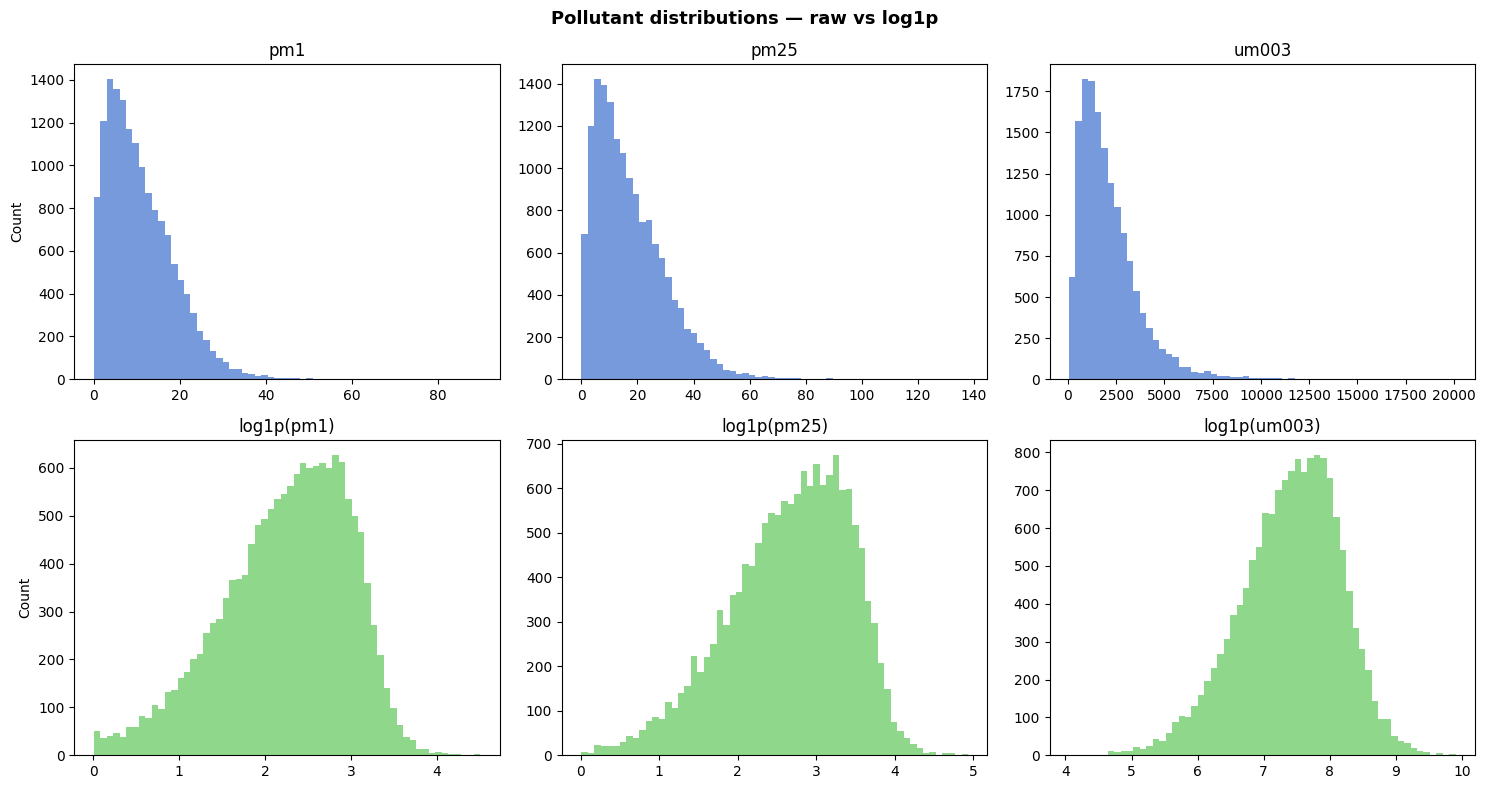

In [ ]:
fig, axes = plt.subplots(2, len(polluants), figsize=(15, 8))
fig.suptitle("Pollutant distributions — raw vs log1p", fontsize=13, fontweight="bold")

for i, col in enumerate(polluants):
    axes[0, i].hist(df[col], bins=60, color="#4878CF", alpha=0.75, edgecolor="none")
    axes[0, i].set_title(col)
    axes[0, i].set_ylabel("Count" if i == 0 else "")

    axes[1, i].hist(np.log1p(df[col]), bins=60, color="#6ACC65", alpha=0.75, edgecolor="none")
    axes[1, i].set_title(f"log1p({col})")
    axes[1, i].set_ylabel("Count" if i == 0 else "")

plt.tight_layout()
plt.show()


### Boxplots — outlier visibility

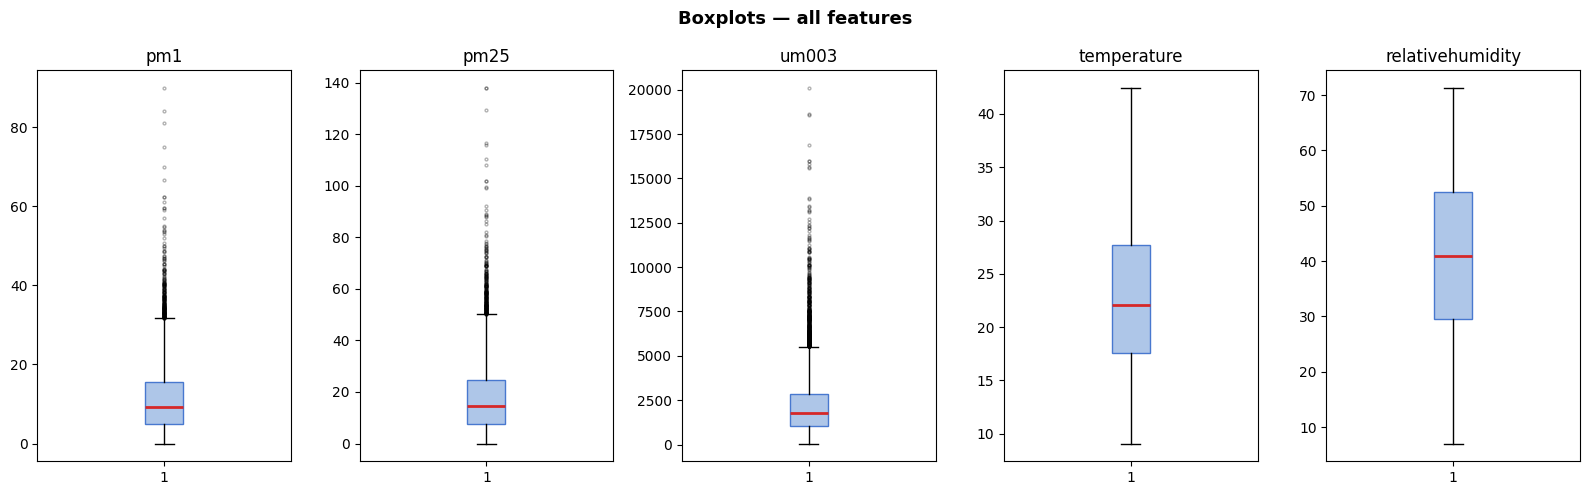

── IQR outlier counts ──
  pm1: 234 outliers (1.5%)
  pm25: 252 outliers (1.7%)
  um003: 561 outliers (3.7%)


In [ ]:
fig, axes = plt.subplots(1, len(all_features), figsize=(16, 5))
fig.suptitle("Boxplots — all features", fontsize=13, fontweight="bold")

for i, col in enumerate(all_features):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor="#AEC6E8", color="#4878CF"),
                    medianprops=dict(color="#D62728", linewidth=2),
                    flierprops=dict(marker="o", markersize=2, alpha=0.3, color="#888"))
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

print("── IQR outlier counts ──")
for col in polluants:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"  {col}: {n_out} outliers ({100*n_out/len(df):.1f}%)")


### Correlation matrix — full cross-pollutant + env features

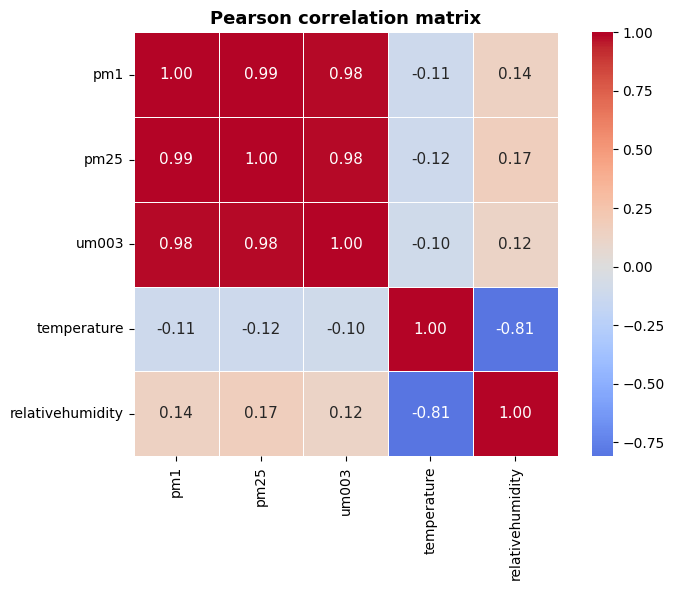

── Correlation with each pollutant target ──

  Target: pm1
pm25                0.990864
um003               0.984133
relativehumidity    0.143051
temperature        -0.112067

  Target: pm25
pm1                 0.990864
um003               0.979212
relativehumidity    0.168493
temperature        -0.115365

  Target: um003
pm1                 0.984133
pm25                0.979212
relativehumidity    0.121554
temperature        -0.098560


In [ ]:
corr = df[all_features].corr(method="pearson")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=True, ax=ax, annot_kws={"size": 11})
ax.set_title("Pearson correlation matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("── Correlation with each pollutant target ──")
for target in polluants:
    preds = [c for c in all_features if c != target]
    print(f"\n  Target: {target}")
    print(corr[target][preds].sort_values(ascending=False).to_string())


### Pairplot — pollutants coloured by monitoring station

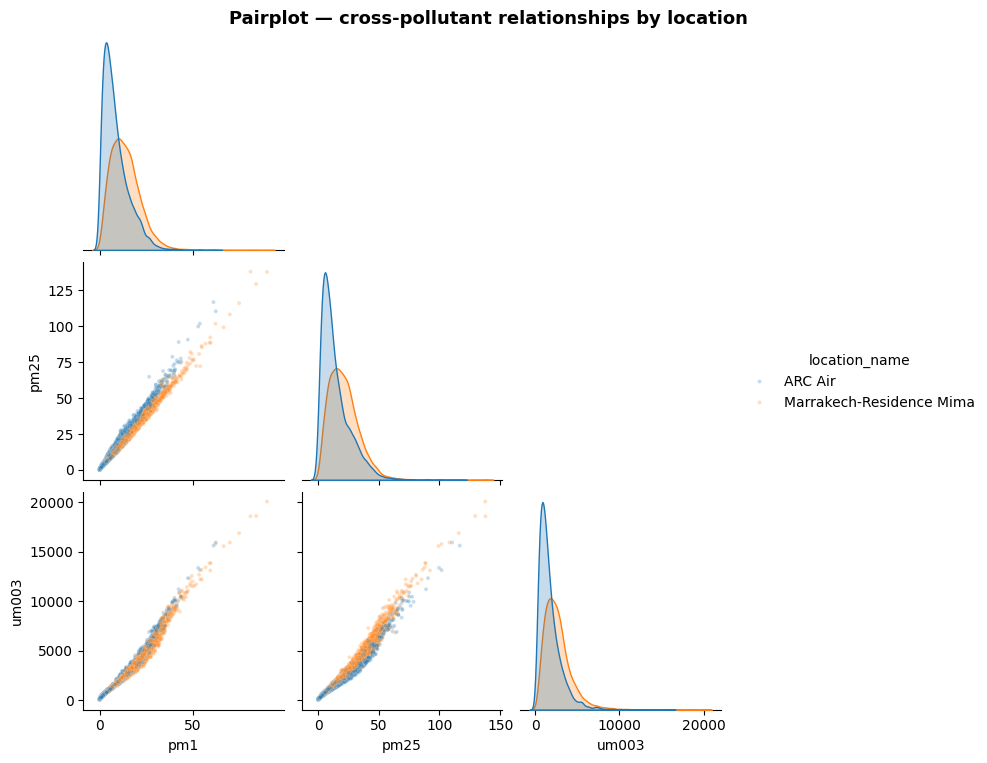

In [ ]:
g = sns.pairplot(
    df[polluants + ['location_name']].reset_index(drop=True),
    hue="location_name",
    plot_kws=dict(alpha=0.25, s=8),
    diag_kind="kde",
    corner=True
)
g.figure.suptitle("Pairplot — cross-pollutant relationships by location",
                   y=1.01, fontsize=13, fontweight="bold")
plt.show()


### Scatter plots — every pollutant pair with regression line

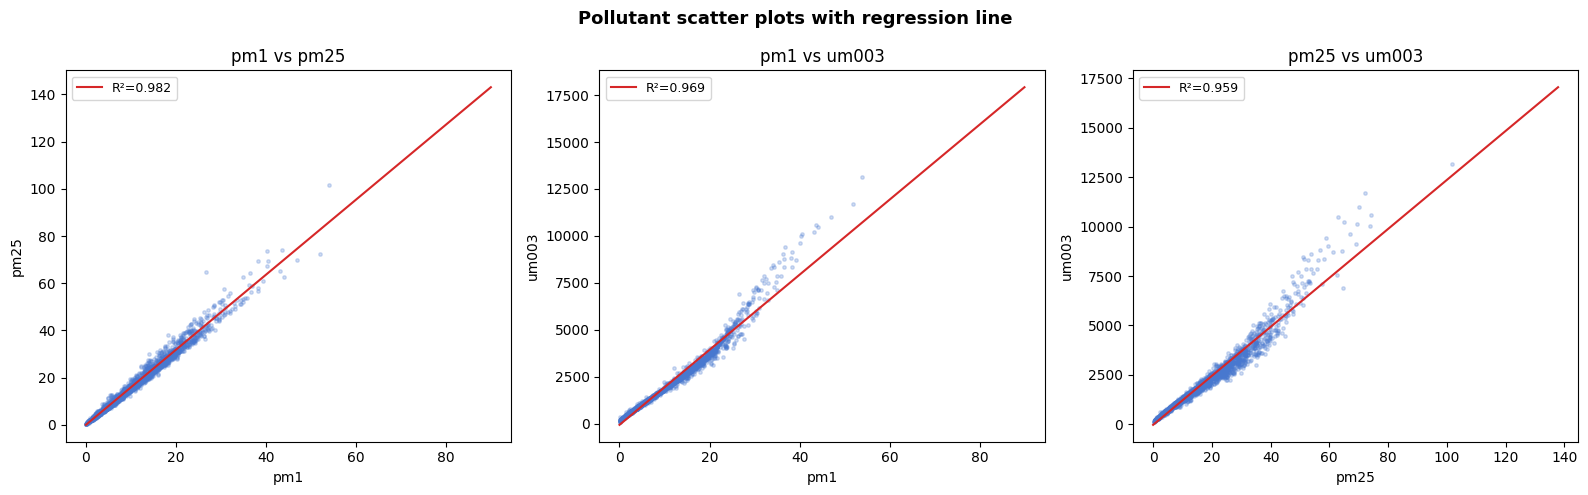

In [ ]:
from itertools import combinations

pairs  = list(combinations(polluants, 2))
colors = ["#4878CF", "#6ACC65", "#D62728"]

fig, axes = plt.subplots(1, len(pairs), figsize=(16, 5))
fig.suptitle("Pollutant scatter plots with regression line", fontsize=13, fontweight="bold")

for ax, (px, py) in zip(axes, pairs):
    sample = df[[px, py]].dropna().sample(min(2000, len(df)), random_state=42)
    ax.scatter(sample[px], sample[py], alpha=0.25, s=6, color="#4878CF")
    m, b, r, *_ = stats.linregress(df[px].dropna(), df[py].dropna())
    x_line = np.linspace(df[px].min(), df[px].max(), 100)
    ax.plot(x_line, m*x_line + b, color="#D62728", linewidth=1.5, label=f"R²={r**2:.3f}")
    ax.set_xlabel(px); ax.set_ylabel(py)
    ax.set_title(f"{px} vs {py}")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


### Time-series — daily mean with 7-day rolling average

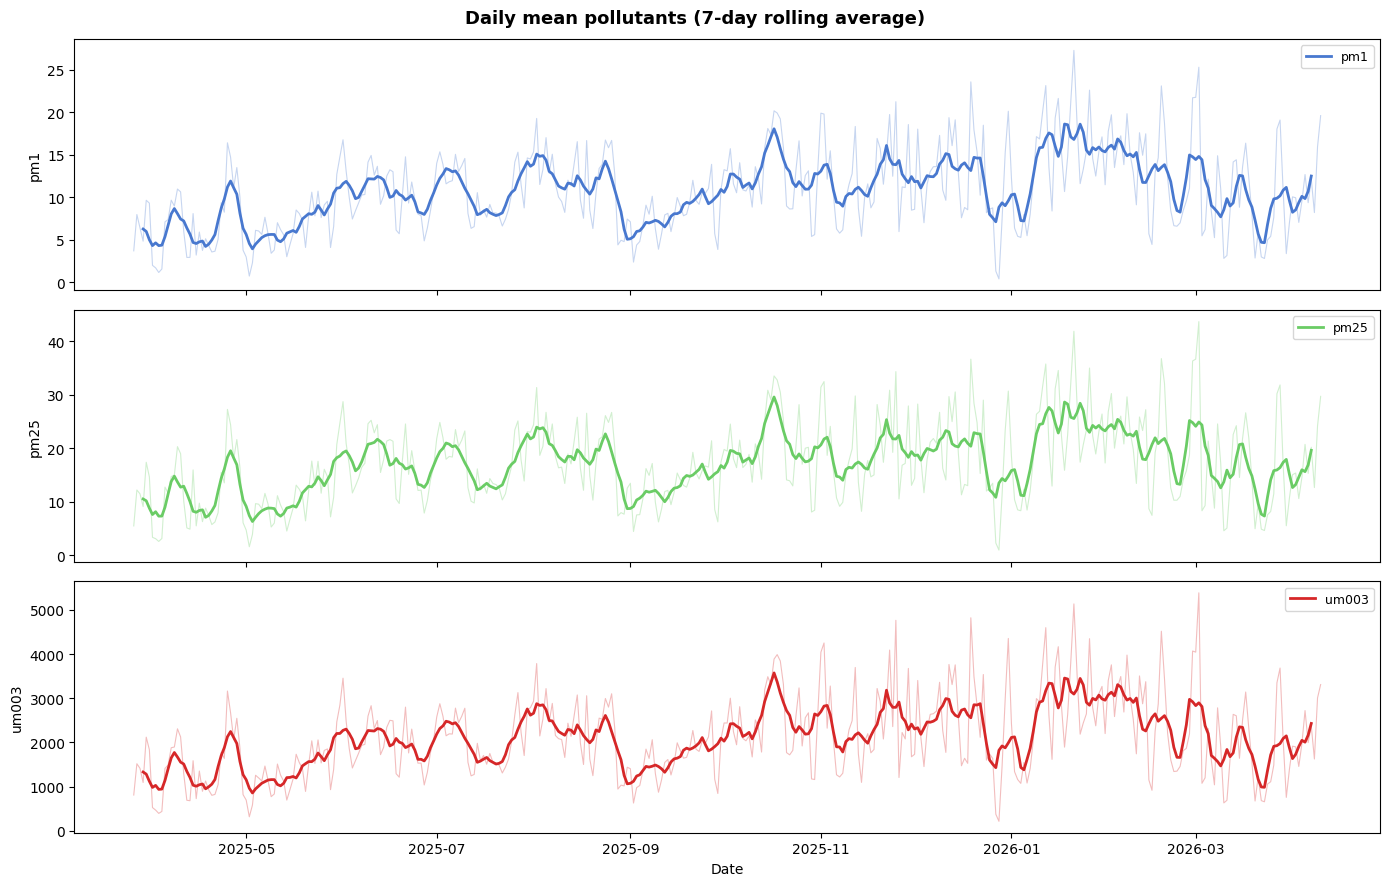

In [ ]:
ts_daily = df[polluants].resample("1D").mean()
ts_roll  = ts_daily.rolling(7, center=True).mean()

plot_colors = ["#4878CF", "#6ACC65", "#D62728"]
fig, axes = plt.subplots(len(polluants), 1, figsize=(14, 9), sharex=True)
fig.suptitle("Daily mean pollutants (7-day rolling average)",
             fontsize=13, fontweight="bold")

for ax, col, color in zip(axes, polluants, plot_colors):
    ax.plot(ts_daily.index, ts_daily[col], alpha=0.3, linewidth=0.8, color=color)
    ax.plot(ts_roll.index,  ts_roll[col],  linewidth=2.0, color=color, label=col)
    ax.set_ylabel(col)
    ax.legend(loc="upper right", fontsize=9)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


### Diurnal pattern — mean pollutant by hour of day

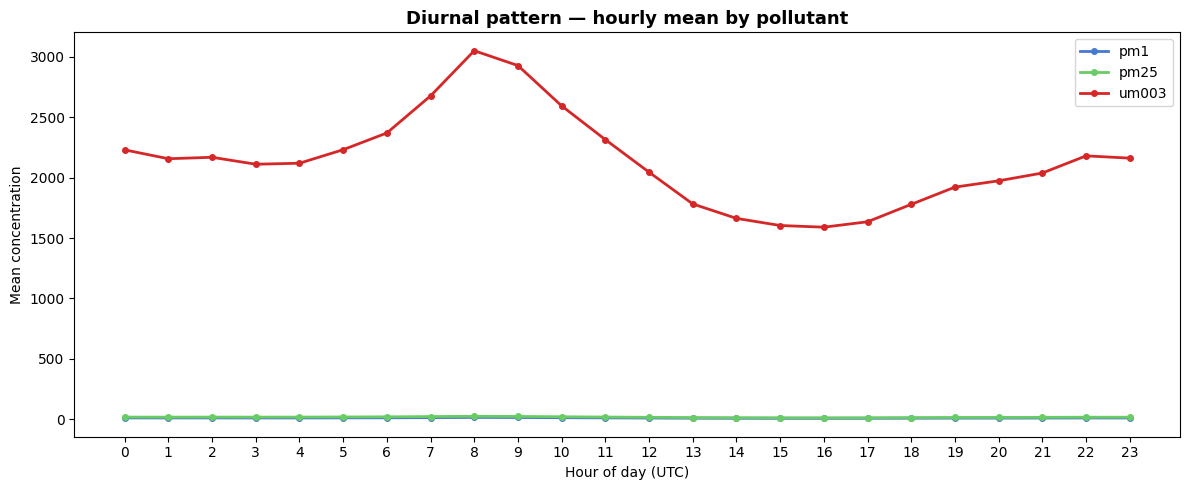

In [ ]:
hourly = df.groupby(df.index.hour)[polluants].mean()

fig, ax = plt.subplots(figsize=(12, 5))
for col, color in zip(polluants, ["#4878CF", "#6ACC65", "#D62728"]):
    ax.plot(hourly.index, hourly[col], marker="o", markersize=4,
            linewidth=2, label=col, color=color)

ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("Mean concentration")
ax.set_title("Diurnal pattern — hourly mean by pollutant",
             fontsize=13, fontweight="bold")
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()


### Environmental features vs pollutants — temperature & humidity effect

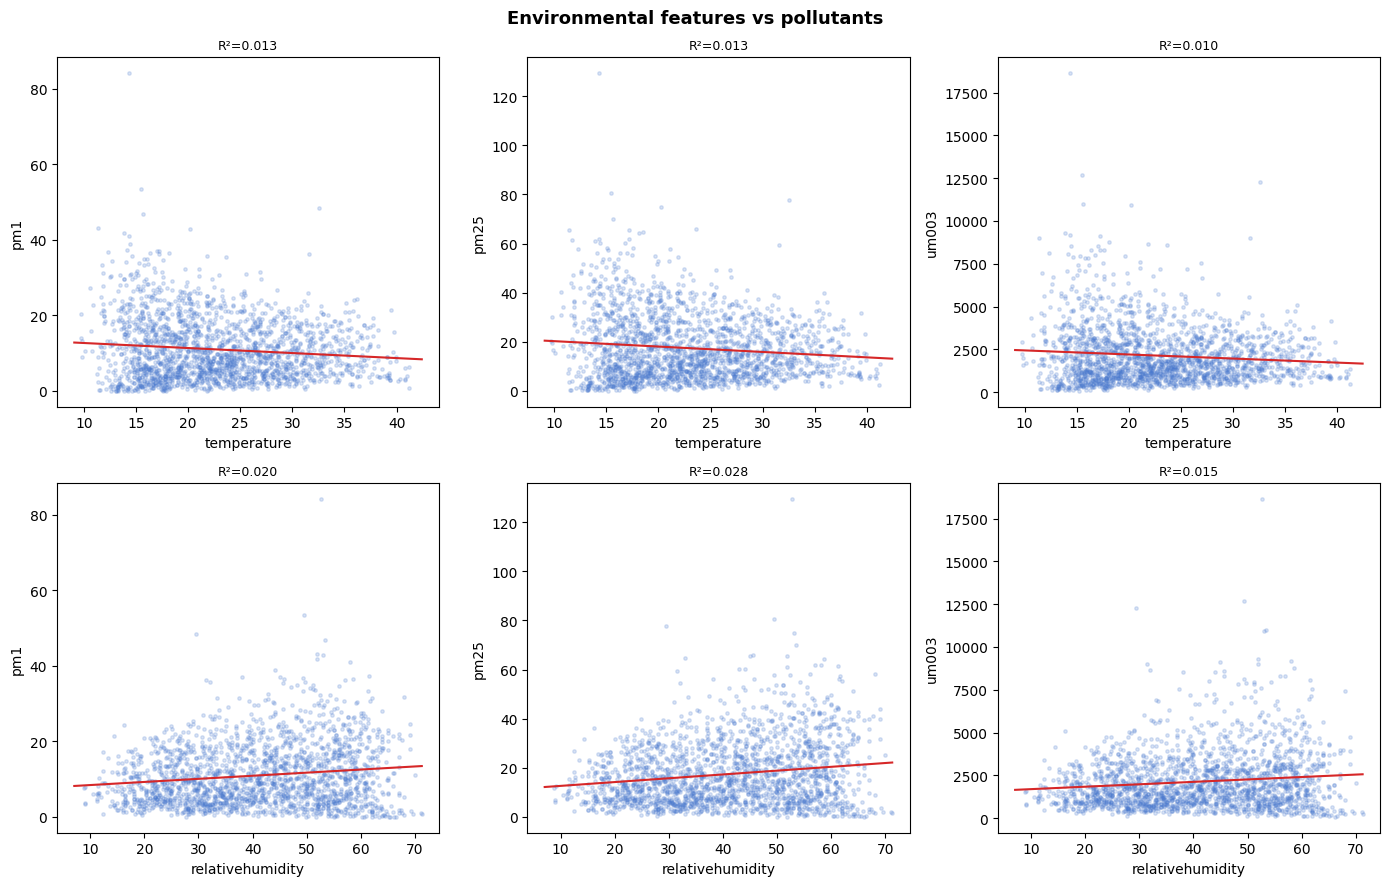

In [ ]:
fig, axes = plt.subplots(len(env_features), len(polluants), figsize=(14, 9))
fig.suptitle("Environmental features vs pollutants",
             fontsize=13, fontweight="bold")

for i, env in enumerate(env_features):
    for j, pol in enumerate(polluants):
        sample = df[[env, pol]].dropna().sample(min(2000, len(df)), random_state=1)
        axes[i, j].scatter(sample[env], sample[pol], alpha=0.2, s=6, color="#4878CF")
        m, b, r, *_ = stats.linregress(df[env].dropna(), df[pol].dropna())
        x_line = np.linspace(df[env].min(), df[env].max(), 100)
        axes[i, j].plot(x_line, m*x_line + b, color="#D62728", linewidth=1.5)
        axes[i, j].set_xlabel(env)
        axes[i, j].set_ylabel(pol)
        axes[i, j].set_title(f"R²={r**2:.3f}", fontsize=9)

plt.tight_layout()
plt.show()


### Per-location breakdown — distribution by monitoring station

── Per-location summary ──
                             pm1                                               \
                           count   mean   std  min   25%    50%    75%    max   
location_name                                                                   
ARC Air                   8212.0   8.55  6.90  0.0  3.41   6.72  11.94  62.43   
Marrakech-Residence Mima  6931.0  13.80  8.09  0.2  7.87  12.77  18.24  89.89   

                            pm25         ...                  um003           \
                           count   mean  ...    75%     max   count     mean   
location_name                            ...                                   
ARC Air                   8212.0  14.30  ...  19.75  116.73  8212.0  1697.65   
Marrakech-Residence Mima  6931.0  21.18  ...  28.07  137.89  6931.0  2651.31   

                                                                                
                              std     min      25%      50%      75%       max  
loca

/tmp/ipykernel_33488/3613312368.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, patch_artist=True,
/tmp/ipykernel_33488/3613312368.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, patch_artist=True,
/tmp/ipykernel_33488/3613312368.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, patch_artist=True,


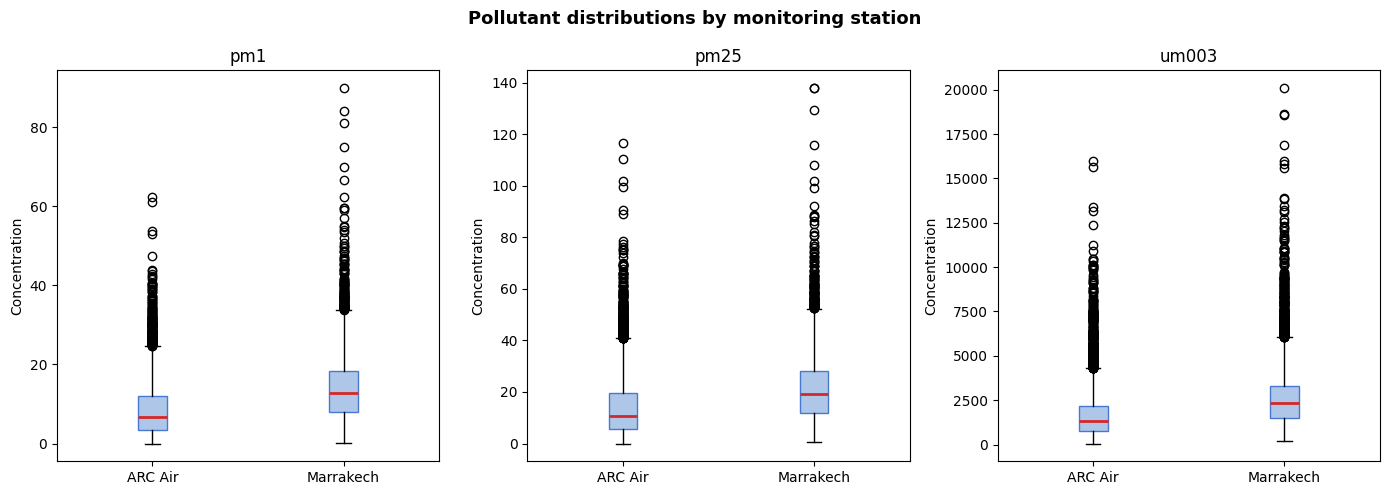

In [ ]:
print("── Per-location summary ──")
print(df.groupby("location_name")[polluants].describe().round(2))

fig, axes = plt.subplots(1, len(polluants), figsize=(14, 5))
fig.suptitle("Pollutant distributions by monitoring station",
             fontsize=13, fontweight="bold")

for ax, col in zip(axes, polluants):
    groups = [grp[col].values for _, grp in df.groupby("location_name")]
    labels  = [name.split("-")[0] for name in df["location_name"].unique()]
    ax.boxplot(groups, labels=labels, patch_artist=True,
               boxprops=dict(facecolor="#AEC6E8", color="#4878CF"),
               medianprops=dict(color="#D62728", linewidth=2))
    ax.set_title(col)
    ax.set_ylabel("Concentration")

plt.tight_layout()
plt.show()


### WHO air quality threshold analysis (PM2.5)

                        count     %
who_category                       
Good (≤5)                2164  14.3
Moderate (5–15)          5556  36.7
Unhealthy (15–25)        3723  24.6
Very unhealthy (25–50)   3442  22.7
Hazardous (>50)           258   1.7


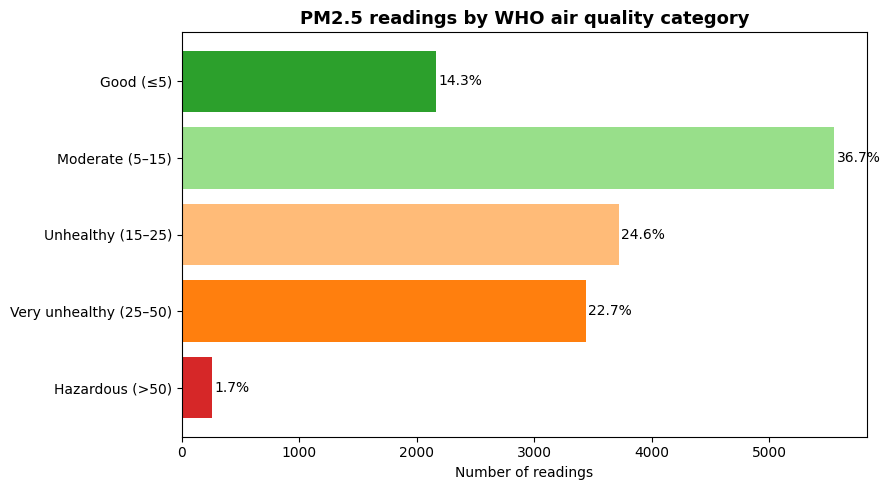

In [ ]:
who_bins   = [0, 5, 15, 25, 50, np.inf]
who_labels = ["Good (≤5)", "Moderate (5–15)", "Unhealthy (15–25)",
              "Very unhealthy (25–50)", "Hazardous (>50)"]

df["who_category"] = pd.cut(df["pm25"], bins=who_bins, labels=who_labels)

counts = df["who_category"].value_counts().reindex(who_labels)
pct    = (counts / counts.sum() * 100).round(1)
print(pd.DataFrame({"count": counts, "%": pct}))

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ["#2ca02c", "#98df8a", "#ffbb78", "#ff7f0e", "#d62728"]
bars = ax.barh(counts.index, counts.values, color=bar_colors, edgecolor="none")
for bar, p in zip(bars, pct.values):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f"{p}%", va="center", fontsize=10)
ax.set_xlabel("Number of readings")
ax.set_title("PM2.5 readings by WHO air quality category",
             fontsize=13, fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Monthly seasonality — mean pollutant per calendar month

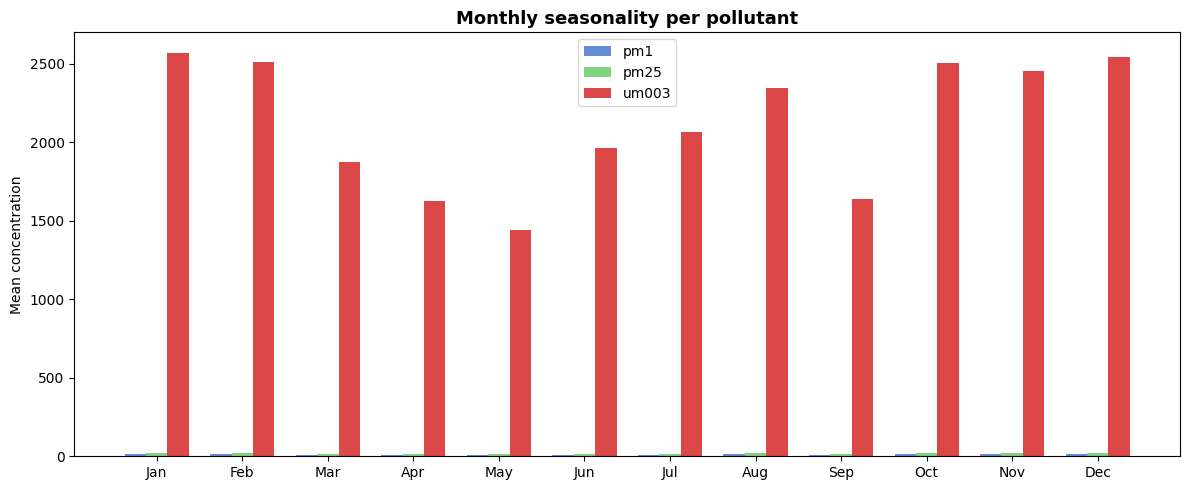

In [ ]:
monthly = df.groupby(df.index.month)[polluants].mean()
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(12)
width = 0.25
for k, (col, color) in enumerate(zip(polluants, ["#4878CF", "#6ACC65", "#D62728"])):
    ax.bar(x + k*width, monthly[col], width, label=col, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(month_labels)
ax.set_ylabel("Mean concentration")
ax.set_title("Monthly seasonality per pollutant", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


## IV. Feature engineering

### Temporal Features

In [ ]:
df['hour']       = df.index.hour
df['dayofweek']  = df.index.dayofweek
df['month']      = df.index.month
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
df['is_rush']    = df['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)

# Cyclic encoding to keep circular continuity
df['hour_sin']  = np.sin(2 * np.pi * df['hour']      / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour']      / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month']     / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month']     / 12)
df['dow_sin']   = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['dow_cos']   = np.cos(2 * np.pi * df['dayofweek'] / 7)

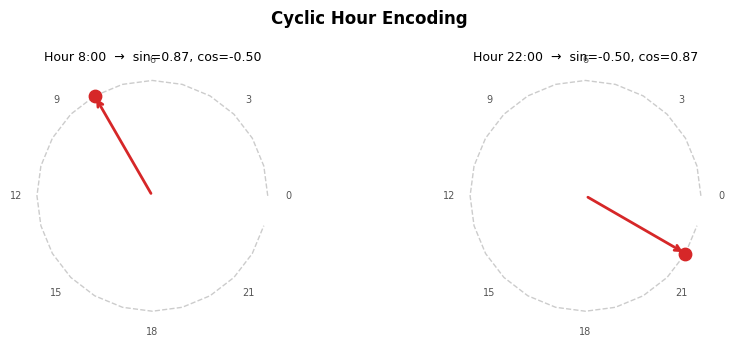

Temporal features created: hour, dayofweek, month, is_weekend, is_rush + 6 cyclic encodings


In [ ]:
theta = np.linspace(0, 2*np.pi, 24, endpoint=False)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, hour in zip(axes, [8, 22]):
    ax.plot(np.cos(theta), np.sin(theta), '--', color='#ccc', lw=1)
    s = np.sin(2*np.pi*hour/24); c = np.cos(2*np.pi*hour/24)
    ax.annotate('', xy=(c, s), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#D62728', lw=2))
    ax.scatter([c], [s], color='#D62728', zorder=5, s=80)
    for h in range(0, 24, 3):
        hx = np.cos(2*np.pi*h/24); hy = np.sin(2*np.pi*h/24)
        ax.text(hx*1.18, hy*1.18, str(h), ha='center', va='center', fontsize=7, color='#555')
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(f'Hour {hour}:00  →  sin={s:.2f}, cos={c:.2f}', fontsize=9)
fig.suptitle('Cyclic Hour Encoding', fontweight='bold')
plt.tight_layout(); plt.show()

print('Temporal features created: hour, dayofweek, month, is_weekend, is_rush + 6 cyclic encodings')


### Rolling window features

In [ ]:
windows = [(1, '1h'), (6, '6h'), (24, '24h'), (72, '72h')]
roll_target_cols = ['pm25', 'pm1','um003', 'temperature', 'relativehumidity']

for loc in df['location_name'].unique():
    mask = df['location_name'] == loc
    for col in roll_target_cols:
        for w, label in windows:
            df.loc[mask, f'{col}_roll_mean_{label}'] = (
                df.loc[mask, col].rolling(w, min_periods=1).mean().values
            )
            df.loc[mask, f'{col}_roll_std_{label}'] = (
                df.loc[mask, col].rolling(w, min_periods=1).std().values
            )
        df.loc[mask, f'{col}_ewm_12h'] = (
            df.loc[mask, col].ewm(span=12, min_periods=1).mean().values
        )

Rolling features: 45 columns


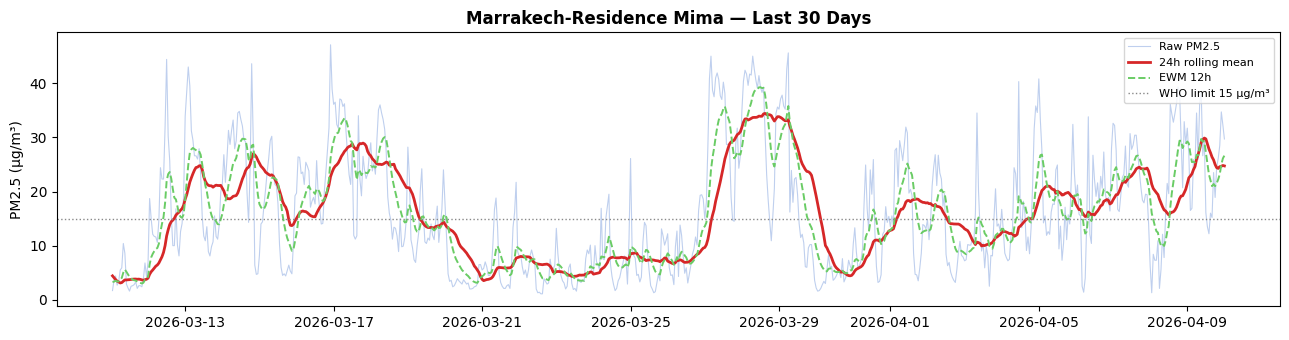

In [ ]:
roll_cols = [c for c in df.columns if 'roll_' in c or 'ewm_' in c]
print(f'Rolling features: {len(roll_cols)} columns')

# raw vs smoothed for Marrakech
loc_sample = 'Marrakech-Residence Mima'
sample = df[df['location_name'] == loc_sample].tail(720)  # ~30 days
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(sample.index, sample['pm25'],               alpha=0.35, lw=0.8, color='#4878CF', label='Raw PM2.5')
ax.plot(sample.index, sample['pm25_roll_mean_24h'], lw=2.0,    color='#D62728',         label='24h rolling mean')
ax.plot(sample.index, sample['pm25_ewm_12h'],       lw=1.4, ls='--', color='#6ACC65',   label='EWM 12h')
ax.axhline(15, ls=':', color='#888', lw=1, label='WHO limit 15 µg/m³')
ax.set_ylabel('PM2.5 (µg/m³)'); ax.set_title(f'{loc_sample} — Last 30 Days', fontweight='bold')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()


### Lag features & rate of change

In [ ]:
for loc in df['location_name'].unique():
    mask = df['location_name'] == loc
    for col in ['pm25', 'pm1','um003']:
        for lag in [1, 2, 3, 6, 12, 24, 48]:
            df.loc[mask, f'{col}_lag_{lag}h'] = df.loc[mask, col].shift(lag).values
        df.loc[mask, f'{col}_delta_1h']  = df.loc[mask, col].diff(1).values
        df.loc[mask, f'{col}_delta_6h']  = df.loc[mask, col].diff(6).values
        df.loc[mask, f'{col}_delta_24h'] = df.loc[mask, col].diff(24).values

lag_cols = [c for c in df.columns if '_lag_' in c or '_delta_' in c]
print(f'Lag + delta features: {len(lag_cols)} columns')

Lag + delta features: 30 columns


/tmp/ipykernel_33488/791791528.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([l.replace('pm25_','') for l in lag_corr.index], rotation=30, ha='right')


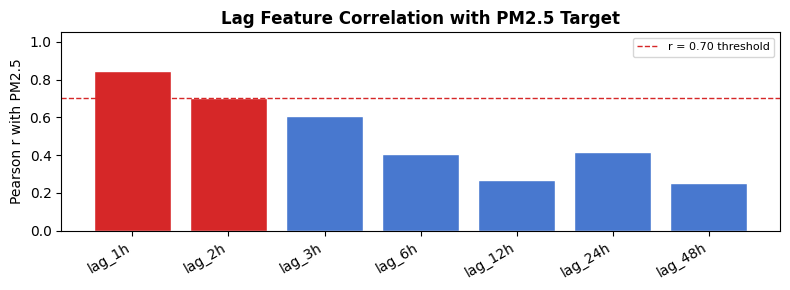

In [ ]:
lag_pm25_cols = [f'pm25_lag_{l}h' for l in [1, 2, 3, 6, 12, 24, 48]]
lag_corr = df[['pm25'] + lag_pm25_cols].corr()['pm25'].drop('pm25')

fig, ax = plt.subplots(figsize=(8, 3))
bar_colors = ['#D62728' if v > 0.7 else '#4878CF' for v in lag_corr.values]
ax.bar(lag_corr.index, lag_corr.values, color=bar_colors, edgecolor='white')
ax.axhline(0.7, ls='--', color='#D62728', lw=1, label='r = 0.70 threshold')
ax.set_ylim(0, 1.05); ax.set_ylabel('Pearson r with PM2.5')
ax.set_title('Lag Feature Correlation with PM2.5 Target', fontweight='bold')
ax.set_xticklabels([l.replace('pm25_','') for l in lag_corr.index], rotation=30, ha='right')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()


### Interaction & derived features

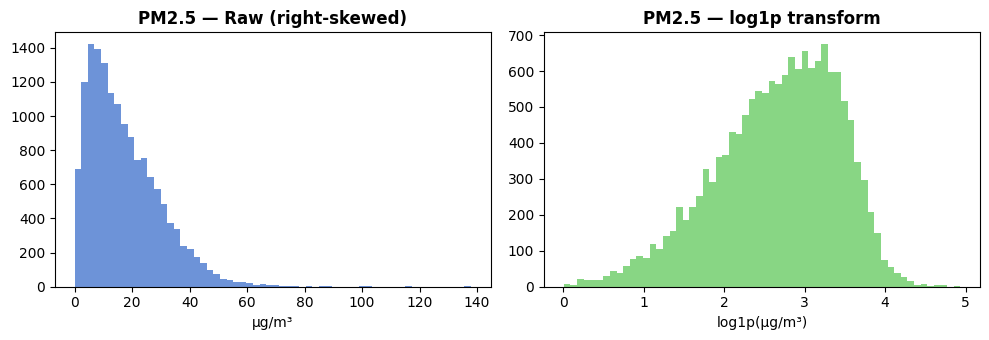

In [ ]:
# Log  transformation to fix the right skew in the data
for col in ['pm25', 'pm1', 'um003']:
    df[f'{col}_log1p'] = np.log1p(df[col])
# heat index -interaction term- since tempature and humidity don't perform well separatly but they impact the pollution when combined
df['heat_index'] = df['temperature'] * df['relativehumidity'] / 100

# PM1/PM2.5 ratio, source type indicator ~1.0(combustion/vehicles (fine particles)),low(dust/resuspension)
df['pm1_pm25_ratio'] = df['pm1'] / df['pm25'].replace(0, np.nan)


# PM2.5 standarization using z-score to spot anomalies
df['pm25_anomaly'] = ((df['pm25'] - df['pm25_roll_mean_24h']) /df['pm25_roll_std_24h'].replace(0, np.nan))

# Location binary flag because we can't predict benguerir pollution level using marrakech data
df['is_marrakech'] = df['location_name'].str.contains('Marrakech', na=False).astype(int)


# visualization of the log transformation
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(df['pm25'].dropna(), bins=60, color='#4878CF', edgecolor='none', alpha=0.8)
axes[0].set_title('PM2.5 — Raw (right-skewed)', fontweight='bold'); axes[0].set_xlabel('µg/m³')
axes[1].hist(df['pm25_log1p'].dropna(), bins=60, color='#6ACC65', edgecolor='none', alpha=0.8)
axes[1].set_title('PM2.5 — log1p transform', fontweight='bold'); axes[1].set_xlabel('log1p(µg/m³)')
plt.tight_layout(); plt.show()



### Feature inventory and save

In [ ]:
df_model = df.dropna(subset=['pm25']).copy()

print(f'Final shape  : {df_model.shape}')
print(f'Date range   : {df_model.index.min().date()} → {df_model.index.max().date()}')
print(f'Locations    : {df_model["location_name"].unique().tolist()}')


Final shape  : (15143, 103)
Date range   : 2025-03-26 → 2026-04-10
Locations    : ['ARC Air', 'Marrakech-Residence Mima']


In [ ]:
categories = {
    'Raw sensors'    : ['pm1', 'pm25', 'relativehumidity', 'temperature', 'um003'],
    'AQI / target'   : ['aqi_category', 'aqi_label', 'is_unhealthy'],
    'Temporal'       : ['hour', 'dayofweek', 'month', 'is_weekend', 'is_rush',
                        'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos'],
    'Rolling means'  : [c for c in df_model.columns if 'roll_mean' in c],
    'Rolling std'    : [c for c in df_model.columns if 'roll_std'  in c],
    'EWM'            : [c for c in df_model.columns if 'ewm_'      in c],
    'Lag features'   : [c for c in df_model.columns if '_lag_'     in c],
    'Delta features' : [c for c in df_model.columns if '_delta_'   in c],
    'Log transforms' : [c for c in df_model.columns if '_log1p'    in c],
    'Interactions'   : ['heat_index', 'pm1_pm25_ratio', 'pm25_anomaly', 'is_marrakech'],
}

In [ ]:
rows = []
for cat, feats in categories.items():
    present = [f for f in feats if f in df_model.columns]
    rows.append({'Category': cat, 'Count': len(present),
                 'Sample features': ', '.join(present[:4])})
summary = pd.DataFrame(rows).set_index('Category')
print(f'\nTotal features: {summary["Count"].sum()}')
display(summary)


Total features: 98


,Count,Sample features
Category,,
Raw sensors,5,"pm1, pm25, relativehumidity, temperature"
AQI / target,0,
Temporal,11,"hour, dayofweek, month, is_weekend"
Rolling means,20,"pm25_roll_mean_1h, pm25_roll_mean_6h, pm25_rol..."
Rolling std,20,"pm25_roll_std_1h, pm25_roll_std_6h, pm25_roll_..."
EWM,5,"pm25_ewm_12h, pm1_ewm_12h, um003_ewm_12h, temp..."
Lag features,21,"pm25_lag_1h, pm25_lag_2h, pm25_lag_3h, pm25_la..."
Delta features,9,"pm25_delta_1h, pm25_delta_6h, pm25_delta_24h, ..."
Log transforms,3,"pm25_log1p, pm1_log1p, um003_log1p"


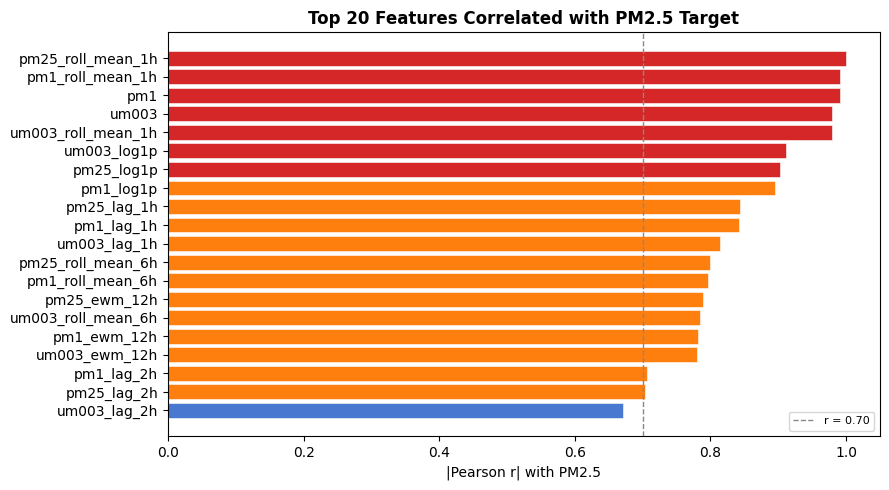

Top 5 predictors:
pm25_roll_mean_1h     1.000000
pm1_roll_mean_1h      0.990864
pm1                   0.990864
um003                 0.979212
um003_roll_mean_1h    0.979212


In [ ]:
# Top features correlated with PM2.5
numeric_df = df_model.select_dtypes(include=[np.number])
corr_with_target = (
    numeric_df.corr()['pm25']
    .drop(['pm25', 'aqi_category', 'is_unhealthy'], errors='ignore')
    .abs().sort_values(ascending=False).head(20)
)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#D62728' if v > 0.9 else '#ff7f0e' if v > 0.7 else '#4878CF'
              for v in corr_with_target.values]
ax.barh(corr_with_target.index[::-1], corr_with_target.values[::-1],
        color=bar_colors[::-1], edgecolor='white', lw=0.4)
ax.axvline(0.7, ls='--', color='#888', lw=1, label='r = 0.70')
ax.set_xlabel('|Pearson r| with PM2.5')
ax.set_title('Top 20 Features Correlated with PM2.5 Target', fontweight='bold')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

print('Top 5 predictors:')
print(corr_with_target.head(5).to_string())


## IV. Machine Learning

### Imports & Setup

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

### Feature selection

In [ ]:
#   - Drop delta features (noisy) and log-transforms (only for EDA)
#   - Drop rolling STD for pm1/um003 (marginal value vs. cost)

target = 'pm25'

features = [
    # Lag features for pm25
    'pm25_lag_1h', 'pm25_lag_2h', 'pm25_lag_3h',
    'pm25_lag_6h', 'pm25_lag_12h', 'pm25_lag_24h', 'pm25_lag_48h',

    # Rolling summaries for pm25
    'pm25_roll_mean_1h', 'pm25_roll_mean_6h',
    'pm25_roll_mean_24h', 'pm25_roll_mean_72h',
    'pm25_roll_std_24h',
    'pm25_ewm_12h',

    # Cross-pollutant
    'pm1',
    'pm1_pm25_ratio',

    # Environmental
    'temperature', 'relativehumidity', 'heat_index',

    # Temporal
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos',
    'dow_sin', 'dow_cos',
    'is_weekend', 'is_rush',

    # Anomaly score
    'pm25_anomaly',

    # Location flag
    'is_marrakech',
]

missing_feats = [f for f in features if f not in df_model.columns]
if missing_feats:
    print(f"Missing: {missing_feats}")
else:
    print(f"All {len(features)} features found. (Reduced from ~98 → {len(features)})")

X = df_model[features]
y = df_model[target]
print(f"Feature matrix shape: {X.shape}")
print(f"Target: '{target}'  |  range: [{y.min():.1f}, {y.max():.1f}] µg/m³")


All 28 features found. (Reduced from ~98 → 28)
Feature matrix shape: (15143, 28)
Target: 'pm25'  |  range: [0.0, 137.9] µg/m³


In [ ]:
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.97)]

if to_drop:
    print(f"Dropping {len(to_drop)} highly correlated features (r > 0.97): {to_drop}")
    X = X.drop(columns=to_drop)
    FEATURES = list(X.columns)
else:
    print("No additional multicollinearity found above r=0.97 threshold")

print(f"Final feature count: {len(FEATURES)}")

Dropping 1 highly correlated features (r > 0.97): ['pm1']
Final feature count: 27


### Temporal train/test split + scaling

In [ ]:
split_idx = int(len(X) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

split_date = X_test.index[0]
print(f"Train: {len(X_train):,} rows  →  up to {X_train.index[-1].date()}")
print(f"Test:  {len(X_test):,}  rows  →  from {split_date.date()}")

# StandardScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

X_train_sc = pd.DataFrame(X_train_sc, columns=FEATURES, index=X_train.index)
X_test_sc  = pd.DataFrame(X_test_sc,  columns=FEATURES, index=X_test.index)


Train: 12,114 rows  →  up to 2026-01-25
Test:  3,029  rows  →  from 2026-01-25


### Time series split cross validation

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

def cv_score(model, X, y, cv):
    rmse_scores, mae_scores = [], []
    for fold, (tr_idx, val_idx) in enumerate(cv.split(X)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        rmse_scores.append(np.sqrt(mean_squared_error(y_val, preds)))
        mae_scores.append(mean_absolute_error(y_val, preds))
        print(f"  Fold {fold+1}: RMSE={rmse_scores[-1]:.3f}  MAE={mae_scores[-1]:.3f}")
    return np.mean(rmse_scores), np.std(rmse_scores), np.mean(mae_scores)

print(" XGBoost CV ")
xgb = XGBRegressor(
    n_estimators=400, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='rmse',
    random_state=42, n_jobs=-1
)
xgb_rmse_cv, xgb_rmse_std, xgb_mae_cv = cv_score(xgb, X_train_sc, y_train, tscv)
print(f"  XGBoost  CV RMSE: {xgb_rmse_cv:.3f} ± {xgb_rmse_std:.3f}")

print("\n── Random Forest CV ──")
rf = RandomForestRegressor(
    n_estimators=200, max_depth=12, min_samples_leaf=5,
    max_features=0.6, random_state=42, n_jobs=-1
)
rf_rmse_cv, rf_rmse_std, rf_mae_cv = cv_score(rf, X_train_sc, y_train, tscv)
print(f"  Random Forest  CV RMSE: {rf_rmse_cv:.3f} ± {rf_rmse_std:.3f}")


 XGBoost CV 
  Fold 1: RMSE=0.438  MAE=0.216
  Fold 2: RMSE=2.093  MAE=0.281
  Fold 3: RMSE=0.814  MAE=0.163
  Fold 4: RMSE=1.480  MAE=0.347
  Fold 5: RMSE=2.112  MAE=0.420
  XGBoost  CV RMSE: 1.387 ± 0.673

── Random Forest CV ──
  Fold 1: RMSE=0.516  MAE=0.137
  Fold 2: RMSE=2.228  MAE=0.230
  Fold 3: RMSE=0.987  MAE=0.120
  Fold 4: RMSE=1.122  MAE=0.245
  Fold 5: RMSE=1.708  MAE=0.245
  Random Forest  CV RMSE: 1.312 ± 0.595


### Final Training & Hold-out Evaluation

In [ ]:
val_cut = int(len(X_train_sc) * 0.85)
#XGboost
xgb_final = XGBRegressor(
    n_estimators=1000, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1
)
xgb_final.fit(
    X_train_sc.iloc[:val_cut], y_train.iloc[:val_cut],
    eval_set=[(X_train_sc.iloc[val_cut:], y_train.iloc[val_cut:])],
    verbose=False
)

# Random Forest
rf_final = RandomForestRegressor(
    n_estimators=300, max_depth=12, min_samples_leaf=5,
    max_features=0.6, random_state=42, n_jobs=-1
)
rf_final.fit(X_train_sc, y_train)

def evaluate(name, model, X_te, y_te):
    preds = model.predict(X_te)
    rmse  = np.sqrt(mean_squared_error(y_te, preds))
    mae   = mean_absolute_error(y_te, preds)
    r2    = r2_score(y_te, preds)
    print(f"{name:20s}  RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.4f}")
    return preds, rmse, mae, r2

print("── Hold-out Test Set Results ──")
xgb_preds, xgb_rmse, xgb_mae, xgb_r2 = evaluate("XGBoost",       xgb_final, X_test_sc, y_test)
rf_preds,  rf_rmse,  rf_mae,  rf_r2  = evaluate("Random Forest",  rf_final,  X_test_sc, y_test)


── Hold-out Test Set Results ──
XGBoost               RMSE=0.846  MAE=0.188  R²=0.9962
Random Forest         RMSE=1.009  MAE=0.101  R²=0.9946


In [ ]:
comparison = pd.DataFrame({
    'Model':        ['XGBoost', 'Random Forest'],
    'CV RMSE':      [f"{xgb_rmse_cv:.3f} ± {xgb_rmse_std:.3f}",
                     f"{rf_rmse_cv:.3f}  ± {rf_rmse_std:.3f}"],
    'CV MAE':       [f"{xgb_mae_cv:.3f}", f"{rf_mae_cv:.3f}"],
    'Test RMSE':    [f"{xgb_rmse:.3f}",   f"{rf_rmse:.3f}"],
    'Test MAE':     [f"{xgb_mae:.3f}",    f"{rf_mae:.3f}"],
    'Test R²':      [f"{xgb_r2:.4f}",     f"{rf_r2:.4f}"],
    'Features':     [len(FEATURES), len(FEATURES)],
})
print(comparison)

           Model         CV RMSE CV MAE Test RMSE Test MAE Test R²  Features
0        XGBoost   1.387 ± 0.673  0.286     0.846    0.188  0.9962        27
1  Random Forest  1.312  ± 0.595  0.195     1.009    0.101  0.9946        27


### Actual vs Predicted Plot

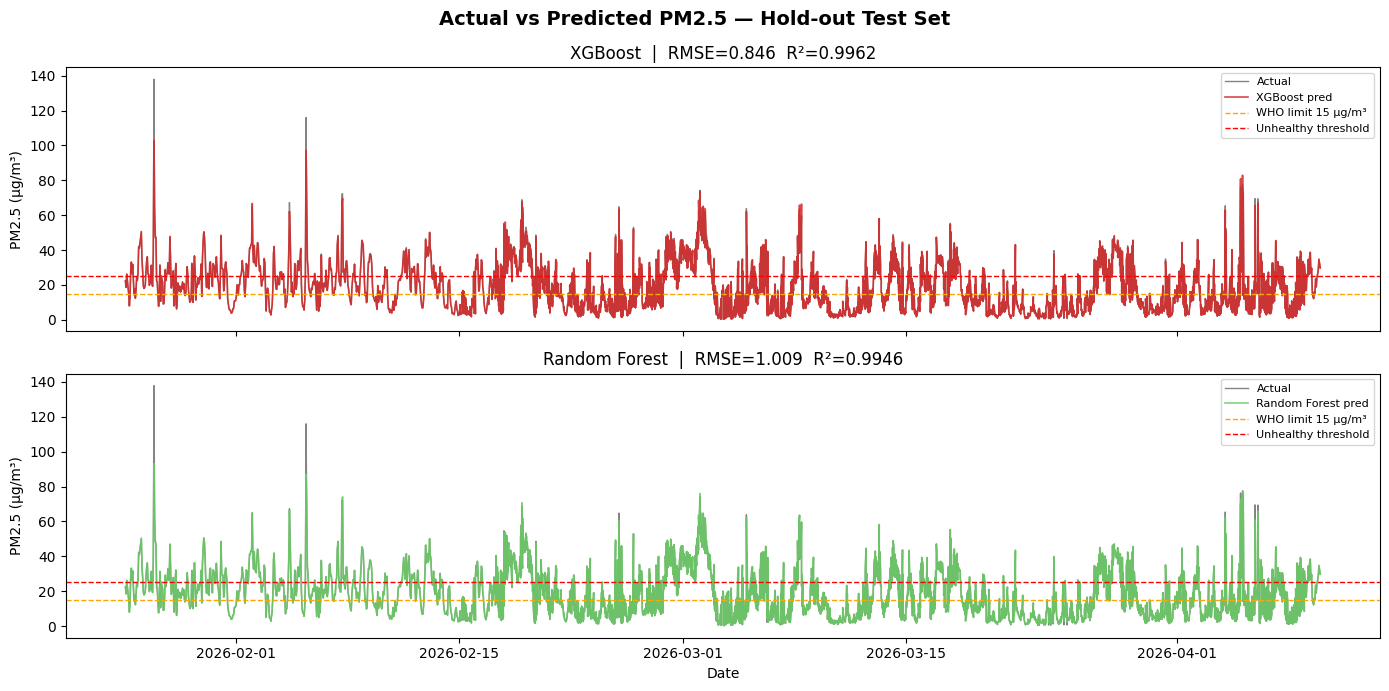

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle('Actual vs Predicted PM2.5 — Hold-out Test Set', fontsize=14, fontweight='bold')

for ax, name, preds, color in zip(
    axes,
    ['XGBoost', 'Random Forest'],
    [xgb_preds, rf_preds],
    ['#D62728', '#6ACC65']
):
    ax.plot(y_test.index, y_test.values,  lw=1.0, alpha=0.6, color='#333', label='Actual')
    ax.plot(y_test.index, preds,           lw=1.2, alpha=0.85, color=color, label=f'{name} pred')
    ax.axhline(15, ls='--', color='orange', lw=1, label='WHO limit 15 µg/m³')
    ax.axhline(25, ls='--', color='red',    lw=1, label='Unhealthy threshold')
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.legend(fontsize=8, loc='upper right')
    ax.set_title(f'{name}  |  RMSE={[xgb_rmse,rf_rmse][["XGBoost","Random Forest"].index(name)]:.3f}  R²={[xgb_r2,rf_r2][["XGBoost","Random Forest"].index(name)]:.4f}')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()


### Random Forest Feature Importance

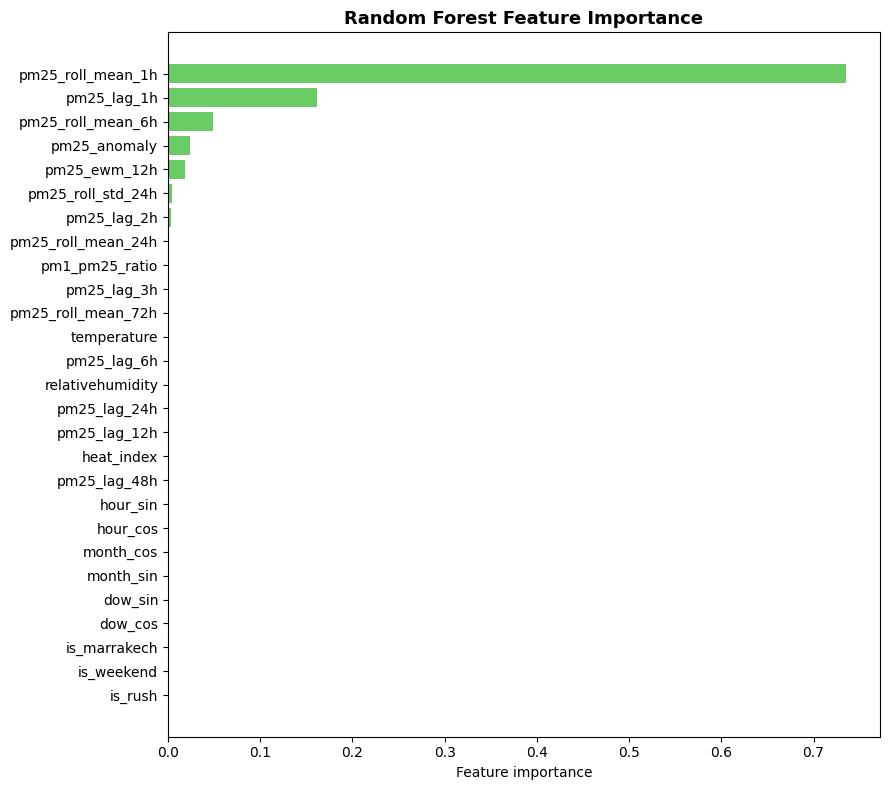


Top 10 most important features:
pm25_roll_mean_1h     0.735311
pm25_lag_1h           0.161174
pm25_roll_mean_6h     0.049295
pm25_anomaly          0.023488
pm25_ewm_12h          0.018975
pm25_roll_std_24h     0.004641
pm25_lag_2h           0.003468
pm25_roll_mean_24h    0.001474
pm1_pm25_ratio        0.000461
pm25_lag_3h           0.000264


In [ ]:
# ── Random Forest Feature Importance (simple + clear) ───────────────────────

rf_importance = pd.Series(
    rf_final.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(9, 8))

colors = ['#6ACC65' if v > rf_importance.median() else '#98df8a'
          for v in rf_importance.values]

ax.barh(rf_importance.index, rf_importance.values,
        color=colors, edgecolor='none')

ax.set_xlabel('Feature importance')
ax.set_title('Random Forest Feature Importance',
             fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 10 features
top10 = rf_importance.nlargest(10)

print("\nTop 10 most important features:")
print(top10.to_string())

## V. Deep Learning — LSTM


### Imports & setup

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')


### LSTM-specific data preparation

LSTM requires **3-D input tensors**: `(samples, timesteps, features)`.

We use a **24-step lookback** (= 24 hours of history) to predict the next hour's PM2.5.

In [ ]:
lstm_feats= ['pm25', 'pm1', 'temperature', 'relativehumidity', 'hour_sin', 'hour_cos']
target        = 'pm25'
lookback      = 24
# We train on campus data (most rows)
# Using df_model which was already cleaned in the ML section above
location_to_use = df_model['location_name'].value_counts().idxmax()
print(f"Training location: {location_to_use}")

loc_df = df_model[df_model['location_name'] == location_to_use][lstm_feats].copy()
loc_df = loc_df.dropna()

print(f"Rows available: {len(loc_df)}")
print(f"Date range: {loc_df.index.min().date()} → {loc_df.index.max().date()}")

Training location: ARC Air
Rows available: 8212
Date range: 2025-03-26 → 2026-04-09


### Scale the data

In [ ]:
split_idx = int(len(loc_df) * 0.80)

train_df = loc_df.iloc[:split_idx]
test_df  = loc_df.iloc[split_idx:]

print(f"Train rows: {len(train_df)}  |  Test rows: {len(test_df)}")
print(f"Train ends : {train_df.index[-1].date()}")
print(f"Test starts: {test_df.index[0].date()}")

# Scale between 0 and 1
scaler_lstm = MinMaxScaler()
train_scaled = scaler_lstm.fit_transform(train_df)
test_scaled  = scaler_lstm.transform(test_df)

print("\nScaling done. All values now between 0 and 1.")

Train rows: 6569  |  Test rows: 1643
Train ends : 2025-12-29
Test starts: 2025-12-29

Scaling done. All values now between 0 and 1.


### Build sequences


In [ ]:
def make_sequences(data, lookback, target_col_idx):
    """
    Converts a 2D array into overlapping sequences for LSTM.

    data           : scaled numpy array of shape (rows, features)
    lookback       : number of past timesteps to use as input (e.g. 24)
    target_col_idx : column index of the variable we want to predict

    Returns:
        X : shape (n_samples, lookback, n_features)  — inputs
        y : shape (n_samples,)                       — targets
    """
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback : i, :])      # past 24 rows, all features
        y.append(data[i, target_col_idx])         # next hour's pm25
    return np.array(X), np.array(y)


# Column index of pm25 in LSTM_FEATURES
pm25_idx = lstm_feats.index(target)

X_train_seq, y_train_seq = make_sequences(train_scaled, lookback, pm25_idx)
X_test_seq,  y_test_seq  = make_sequences(test_scaled,  lookback, pm25_idx)

print(f"X_train shape: {X_train_seq.shape}   →  (samples, lookback=24, features=6)")
print(f"X_test  shape: {X_test_seq.shape}")
print(f"y_train shape: {y_train_seq.shape}    →  (samples,)")

X_train shape: (6545, 24, 6)   →  (samples, lookback=24, features=6)
X_test  shape: (1619, 24, 6)
y_train shape: (6545,)    →  (samples,)


### Step 5 — Build the LSTM model


In [ ]:
tf.random.set_seed(42)

model = Sequential([
    # LSTM layer: reads the 24-hour sequence and returns a single summary vector
    LSTM(64, input_shape=(lookback, len(lstm_feats))),

    # Dropout: randomly ignores 20% of LSTM outputs during training
    # This prevents the model from memorizing training data (overfitting)
    Dropout(0.2),

    # Output layer: one neuron = one predicted value (PM2.5 at next hour)
    Dense(1)
])

# 'adam' is a standard optimizer that adjusts learning rate automatically
# 'mse' = mean squared error — the loss function we minimize during training
model.compile(optimizer='adam', loss='mse')

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,241 (71.25 KB)

 Trainable params: 18,241 (71.25 KB)

 Non-trainable params: 0 (0.00 B)

### Train the model


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=30,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTraining stopped at epoch {len(history.history['loss'])}")

Epoch 1/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0076 - val_loss: 0.0063
Epoch 2/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0045 - val_loss: 0.0056
Epoch 3/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0039 - val_loss: 0.0054
Epoch 4/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0035 - val_loss: 0.0051
Epoch 5/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0034 - val_loss: 0.0051
Epoch 6/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0033 - val_loss: 0.0049
Epoch 7/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0031 - val_loss: 0.0048
Epoch 8/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0031 - val_loss: 0.0047
Epoch 9/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0030 - val_loss: 0.0047
Epoch 10/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0030 - val_loss: 0.0047
Epoch 11/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0029 - val_loss: 0.0047
Epoch 12/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/st

### Training curve


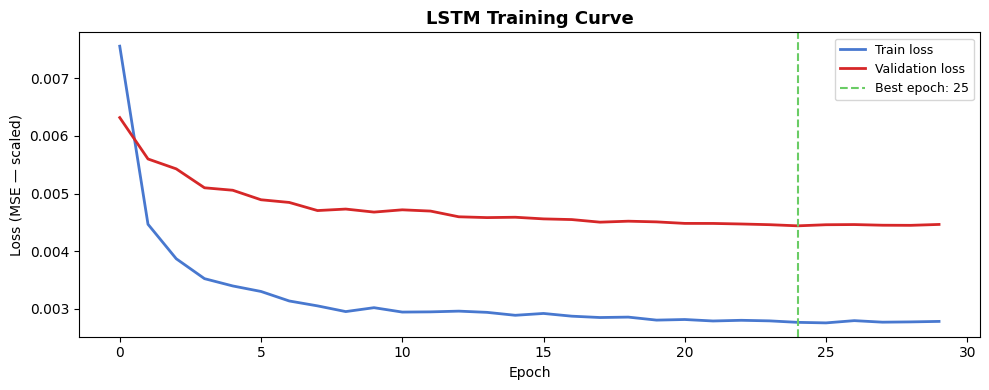

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(history.history['loss'],     label='Train loss',      color='#4878CF', lw=2)
ax.plot(history.history['val_loss'], label='Validation loss', color='#D62728', lw=2)

best_epoch = np.argmin(history.history['val_loss'])
ax.axvline(best_epoch, ls='--', color='#6ACC65', lw=1.5, label=f'Best epoch: {best_epoch+1}')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE — scaled)')
ax.set_title('LSTM Training Curve', fontweight='bold', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Evaluate on the test set


In [ ]:
# Predict on test sequences
y_pred_scaled = model.predict(X_test_seq, verbose=0)

# Inverse-transform: rebuild dummy array → insert pm25 predictions → invert
def inverse_pm25(scaled_values, scaler, pm25_idx, n_features):
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, pm25_idx] = scaled_values.flatten()
    return scaler.inverse_transform(dummy)[:, pm25_idx]

n_features = len(lstm_feats)

y_pred_real = inverse_pm25(y_pred_scaled, scaler_lstm, pm25_idx, n_features)
y_test_real = inverse_pm25(y_test_seq.reshape(-1, 1), scaler_lstm, pm25_idx, n_features)

# Metrics
lstm_rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
lstm_mae  = mean_absolute_error(y_test_real, y_pred_real)

print(f"LSTM  RMSE : {lstm_rmse:.3f} µg/m³")
print(f"LSTM  MAE  : {lstm_mae:.3f}  µg/m³")

LSTM  RMSE : 7.036 µg/m³
LSTM  MAE  : 4.348  µg/m³


### Actual vs Predicted plot


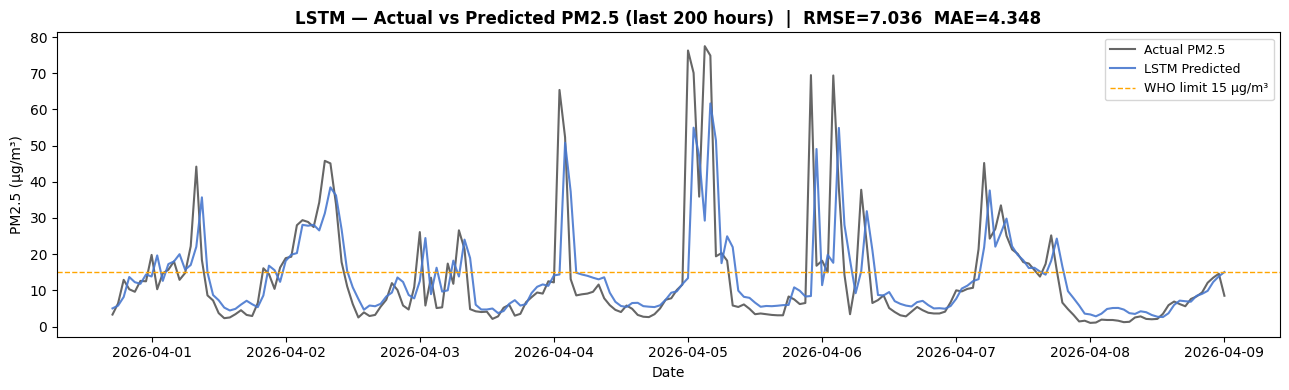

In [ ]:
# Recover the datetime index for test predictions
# (first LOOKBACK rows of test are consumed to build the first sequence)
test_index = test_df.index[lookback:]

# Trim to last 200 hours for clarity
N = 200
plot_idx   = test_index[-N:]
plot_actual = y_test_real[-N:]
plot_pred   = y_pred_real[-N:]

fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(plot_idx, plot_actual, lw=1.5, color='#333333', alpha=0.75, label='Actual PM2.5')
ax.plot(plot_idx, plot_pred,   lw=1.5, color='#4878CF', alpha=0.90, label='LSTM Predicted')
ax.axhline(15, ls='--', color='orange', lw=1, label='WHO limit 15 µg/m³')

ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_xlabel('Date')
ax.set_title(
    f'LSTM — Actual vs Predicted PM2.5 (last {N} hours)  |  RMSE={lstm_rmse:.3f}  MAE={lstm_mae:.3f}',
    fontweight='bold', fontsize=12
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('lstm_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

### Final Model Comparison Table


In [ ]:
import pandas as pd
comparison_final = pd.DataFrame({
    'Model'       : ['XGBoost', 'Random Forest', 'LSTM'],
    'Test RMSE'   : [f"{xgb_rmse:.3f}", f"{rf_rmse:.3f}", f"{lstm_rmse:.3f}"],
    'Test MAE'    : [f"{xgb_mae:.3f}",  f"{rf_mae:.3f}",  f"{lstm_mae:.3f}"],
    'Test R²'     : [f"{xgb_r2:.4f}",   f"{rf_r2:.4f}",   r2_score(y_test_real, y_pred_real)],
    'Approach'    : ['Lag+Rolling features', 'Lag+Rolling features', 'Raw sequence (24h lookback)'],
    'Manual FE?'  : ['Yes', 'Yes', 'No — learned automatically'],
})

print(comparison_final.to_string(index=False))

        Model Test RMSE Test MAE   Test R²                    Approach                 Manual FE?
      XGBoost     0.846    0.188    0.9962        Lag+Rolling features                        Yes
Random Forest     1.009    0.101    0.9946        Lag+Rolling features                        Yes
         LSTM     7.036    4.348  0.733716 Raw sequence (24h lookback) No — learned automatically


## VI. Geospatial Analysis

### Imports & Setup

In [ ]:
import folium
from folium.plugins import HeatMap
import geopandas as gpd
from shapely.geometry import Point
import warnings
warnings.filterwarnings('ignore')

# Station-level aggregate stats
station_summary = (
    df_model.groupby('location_name')
    .agg(
        latitude=('latitude', 'first'),
        longitude=('longitude', 'first'),
        pm25_mean=('pm25', 'mean'),
        pm25_max=('pm25', 'max'),
        pm25_std=('pm25', 'std'),
        n_readings=('pm25', 'count'),
        pct_unhealthy=('pm25', lambda x: (x > 15).mean() * 100)
    )
    .reset_index()
)

print(station_summary[['location_name','latitude','longitude','pm25_mean','pct_unhealthy']].round(2))


              location_name  latitude  longitude  pm25_mean  pct_unhealthy
0                   ARC Air     32.22      -7.93      14.30          35.78
1  Marrakech-Residence Mima     31.66      -8.03      21.18          64.71


### Build GeoDataFrame

In [ ]:
geometry = [Point(xy) for xy in zip(station_summary['longitude'], station_summary['latitude'])]
gdf = gpd.GeoDataFrame(station_summary, geometry=geometry, crs='EPSG:4326')

print(f'GeoDataFrame: {len(gdf)} stations')
print(gdf[['location_name','pm25_mean','pct_unhealthy','geometry']].to_string())


GeoDataFrame: 2 stations
              location_name  pm25_mean  pct_unhealthy                   geometry
0                   ARC Air  14.296503      35.776912  POINT (-7.93107 32.21932)
1  Marrakech-Residence Mima  21.179631      64.709277  POINT (-8.02788 31.66097)


### Hotspot Detection — WHO Exceedance Flags

In [ ]:
# Flag stations exceeding WHO guidelines
# WHO annual guideline: 5 µg/m³  |  WHO 24h limit: 15 µg/m³
gdf['who_annual_flag'] = gdf['pm25_mean'] > 5
gdf['who_daily_flag']  = gdf['pct_unhealthy'] > 20  # >20% of readings above 15

print('── WHO Threshold Flags ──')
print(gdf[['location_name','pm25_mean','pct_unhealthy','who_annual_flag','who_daily_flag']].to_string())

hotspots = gdf[gdf['who_annual_flag']]
print(f'\nHotspot stations (mean PM2.5 > 5 µg/m³): {len(hotspots)} / {len(gdf)}')


── WHO Threshold Flags ──
              location_name  pm25_mean  pct_unhealthy  who_annual_flag  who_daily_flag
0                   ARC Air  14.296503      35.776912             True            True
1  Marrakech-Residence Mima  21.179631      64.709277             True            True

Hotspot stations (mean PM2.5 > 5 µg/m³): 2 / 2


### PM2.5 Folium Heatmap — All Readings

In [ ]:
heat_data = (
    df_model[['latitude', 'longitude', 'pm25']]
    .dropna()
    .values.tolist()
)

center_lat = df_model['latitude'].mean()
center_lon = df_model['longitude'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=10, tiles='CartoDB positron')

HeatMap(
    heat_data,
    radius=20, blur=15, min_opacity=0.4,
    gradient={'0.4': 'blue', '0.65': 'lime', '0.8': 'orange', '1.0': 'red'},
    name='PM2.5 Heatmap'
).add_to(m)

for _, row in gdf.iterrows():
    color = 'red' if row['who_annual_flag'] else 'green'
    popup_html = (
        f"<b>{row['location_name']}</b><br>"
        f"Mean PM2.5: {row['pm25_mean']:.1f} µg/m³<br>"
        f"Max PM2.5:  {row['pm25_max']:.1f} µg/m³<br>"
        f"% above WHO 15: {row['pct_unhealthy']:.1f}%<br>"
        f"Readings: {row['n_readings']:,}"
    )
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=10, color=color, fill=True, fill_opacity=0.8,
        popup=folium.Popup(popup_html, max_width=220),
        tooltip=row['location_name']
    ).add_to(m)

folium.LayerControl().add_to(m)
m.save('pm25_heatmap.html')
print('Heatmap saved: pm25_heatmap.html')
m


Heatmap saved: pm25_heatmap.html


### Station Time-Series Comparison

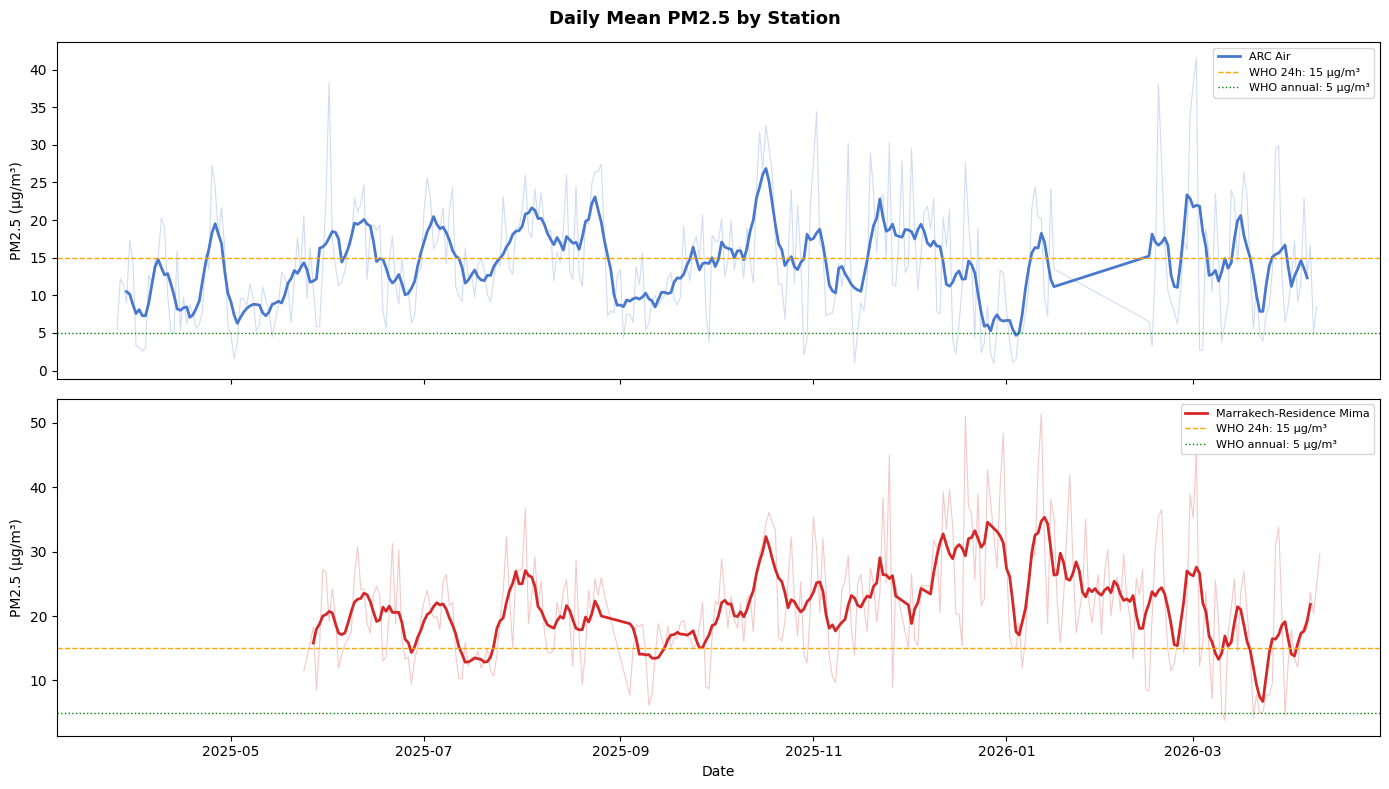

In [ ]:
locations = df_model['location_name'].unique()
colors    = ['#4878CF', '#D62728', '#6ACC65', '#FF7F0E']

fig, axes = plt.subplots(len(locations), 1, figsize=(14, 4 * len(locations)), sharex=True)
if len(locations) == 1:
    axes = [axes]

fig.suptitle('Daily Mean PM2.5 by Station', fontsize=13, fontweight='bold')

for ax, loc, color in zip(axes, locations, colors):
    loc_ts = df_model[df_model['location_name'] == loc]['pm25'].resample('1D').mean().dropna()
    roll7  = loc_ts.rolling(7, center=True).mean()
    ax.plot(loc_ts.index, loc_ts.values, alpha=0.25, lw=0.8, color=color)
    ax.plot(roll7.index,  roll7.values,  lw=2.0, color=color, label=loc)
    ax.axhline(15, ls='--', color='orange', lw=1, label='WHO 24h: 15 µg/m³')
    ax.axhline(5,  ls=':',  color='green',  lw=1, label='WHO annual: 5 µg/m³')
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('station_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### Seasonal Decomposition — Best Station

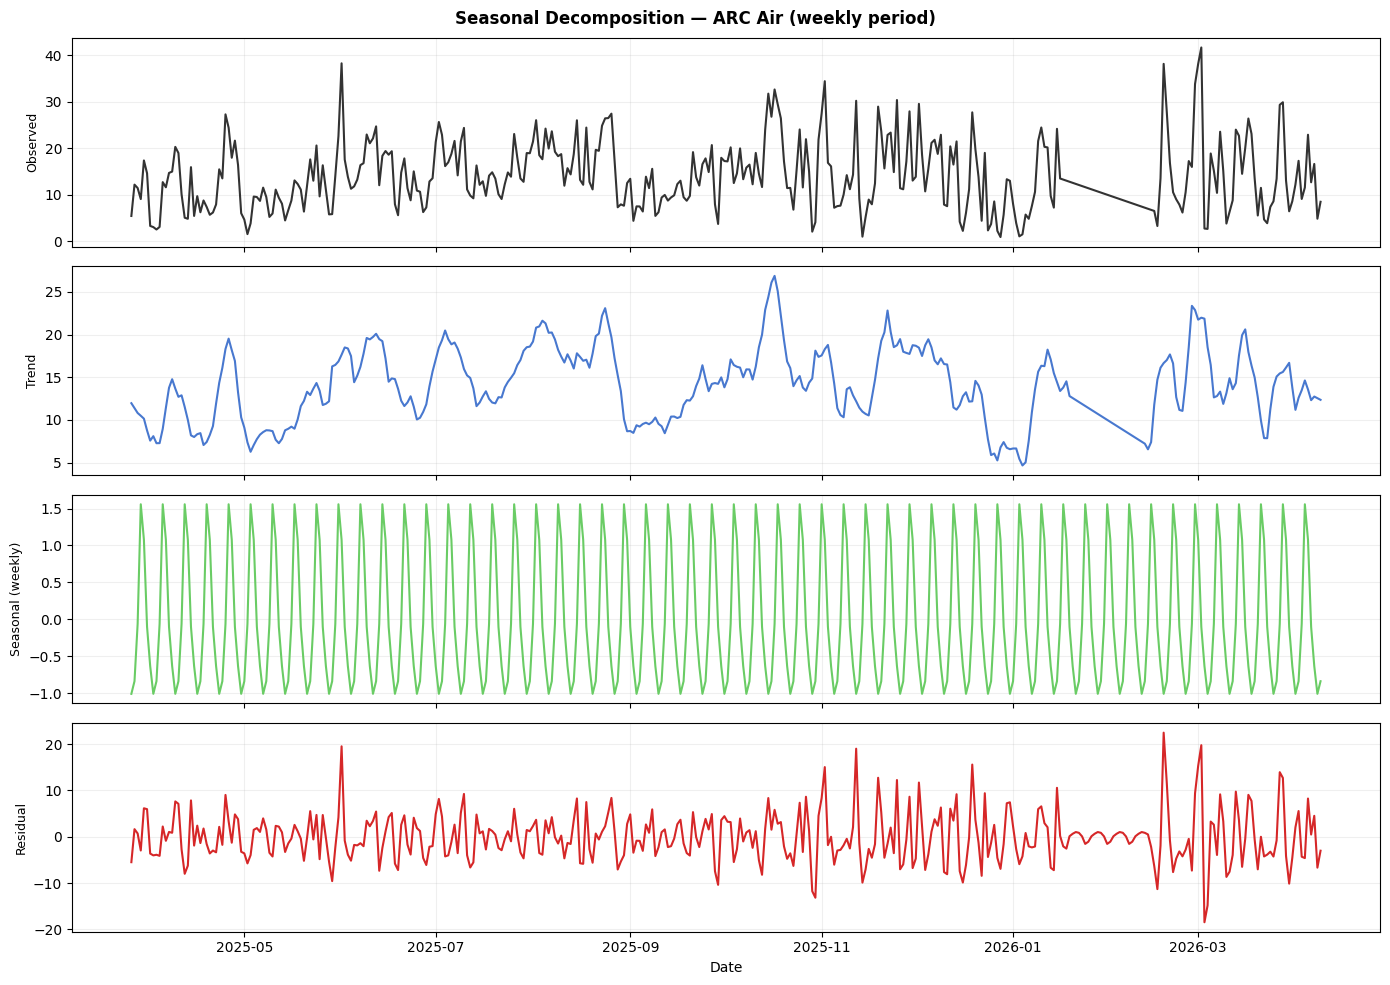

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

best_loc = df_model['location_name'].value_counts().idxmax()
ts_daily = (
    df_model[df_model['location_name'] == best_loc]['pm25']
    .resample('1D').mean()
    .interpolate()
)

if len(ts_daily) >= 14:
    decomp = seasonal_decompose(ts_daily, model='additive', period=7, extrapolate_trend='freq')

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f'Seasonal Decomposition — {best_loc} (weekly period)',
                 fontsize=12, fontweight='bold')

    for ax, data, label, color in zip(
        axes,
        [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid],
        ['Observed', 'Trend', 'Seasonal (weekly)', 'Residual'],
        ['#333', '#4878CF', '#6ACC65', '#D62728']
    ):
        ax.plot(data.index, data.values, lw=1.5, color=color)
        ax.set_ylabel(label, fontsize=9)
        ax.grid(alpha=0.2)

    axes[-1].set_xlabel('Date')
    plt.tight_layout()
    plt.savefig('decomposition.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'Not enough daily data for decomposition ({len(ts_daily)} days, need 14+)')


### Bubble Map — Station Summary (GeoPandas)

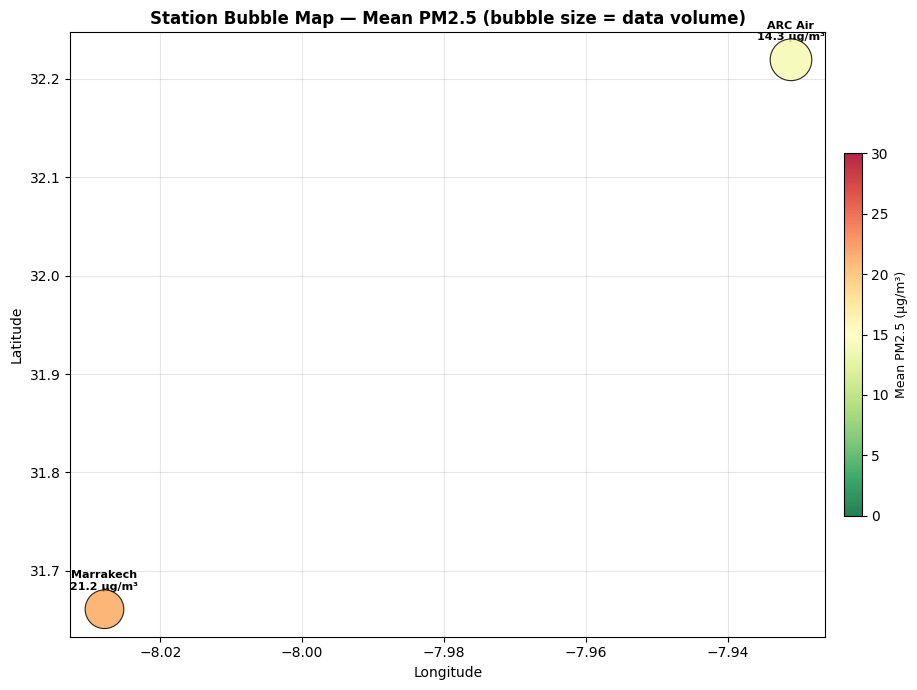


── Final Station Summary ──
           location_name  pm25_mean  pm25_max  pct_unhealthy  n_readings
                 ARC Air      14.30    116.73          35.78        8212
Marrakech-Residence Mima      21.18    137.89          64.71        6931


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    gdf['longitude'], gdf['latitude'],
    s=gdf['n_readings'] / gdf['n_readings'].max() * 800 + 100,
    c=gdf['pm25_mean'],
    cmap='RdYlGn_r', vmin=0, vmax=30,
    edgecolors='black', linewidths=0.8,
    alpha=0.85, zorder=5
)

for _, row in gdf.iterrows():
    ax.annotate(
        f"{row['location_name'].split('-')[0]}\n{row['pm25_mean']:.1f} µg/m³",
        xy=(row['longitude'], row['latitude']),
        xytext=(0, 14), textcoords='offset points',
        ha='center', fontsize=8, fontweight='bold'
    )

cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Mean PM2.5 (µg/m³)', fontsize=9)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Station Bubble Map — Mean PM2.5 (bubble size = data volume)',
             fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('bubble_map.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n── Final Station Summary ──')
print(gdf[['location_name','pm25_mean','pm25_max','pct_unhealthy','n_readings']].round(2).to_string(index=False))
